In [1]:
# The following line is needed to use ipympl backend in Jupyter notebooks
# It enables interactive plots to get data from plot
# %matplotlib ipympl
from wavesongs.object import Syllable, Song, Synthetic
from wavesongs.data.manager import ProjDirs
from wavesongs.utils import plot
from wavesongs.data.download import xc_url
from wavesongs.utils.math import sinusoidal, fitting, gaussian, exponential

# Functions to generate synthetic data
from wavesongs.core.bird import Model

Downloaded audio to XC422161 - Rufous-collared Sparrow - Zonotrichia capensis.mp3


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


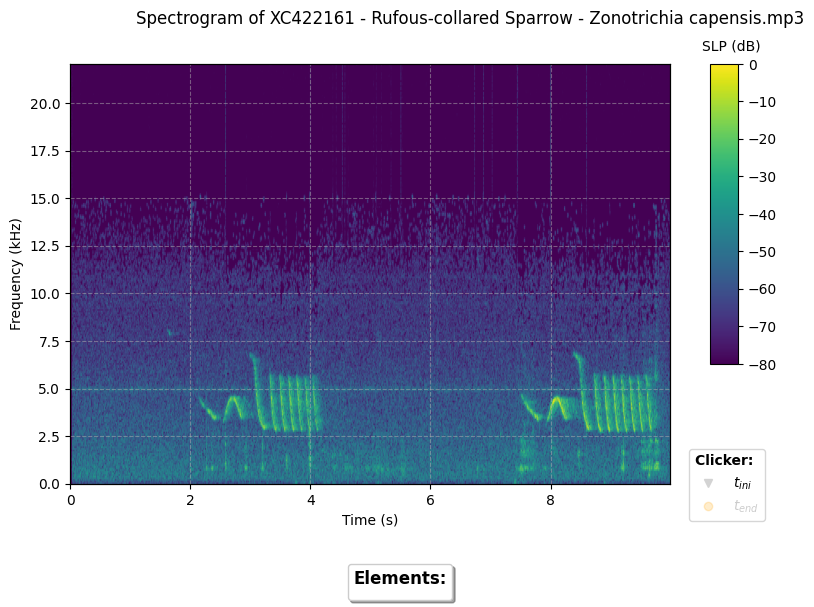

In [2]:
# Download the audio file
file_name = xc_url("https://xeno-canto.org/422161/download")
# Define project directory and plotter objects
proj_dirs = ProjDirs(audios='.')
ploter = plot.set_plotter()

# Define the bem te vi song and compute acoustical features
btv = Song(file_id=file_name , tlim=(0, 10), proj_dirs=proj_dirs) 
btv.acoustical_features(umbral_FF=1.2, n_fft=512, ff_method="yin")
  
# This enables clicking on the spectrogram to get time and frequency values
# Since we are working ina siples example the times were previously clickeed
clicker = ploter.spectrogram(btv, type="2d", ff=False, click="time")

Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


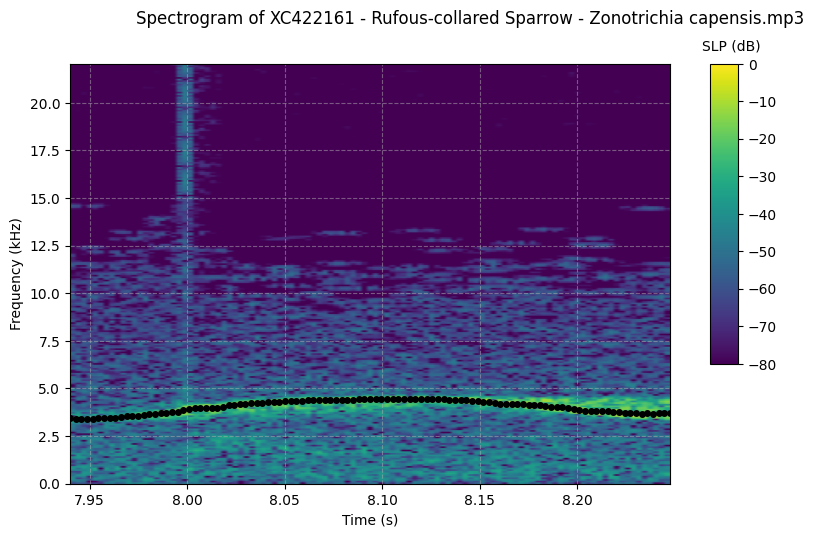

In [3]:
# enable it if you selected the data from the previous cell
# times = plot.get_roi(clicker)
times = [
    # -------------------- theme ------------- # Syllable No.
    (7.51, 7.79), (7.94, 8.26), (8.38, 8.64),  # 1, 2, 3
    # -------------------- trill -------------
    (8.72, 8.85), (8.88, 8.99), (9.03, 9.14),  # 4, 5, 6
    (9.17, 9.27), (9.31, 9.41), (9.44, 9.54), (9.59, 9.68)  # 7, 8, 9, 10
]

# Create a song using the second syllable, index 1, and compute its acoustical features
btv_0 = Song(file_id=file_name , tlim=times[1], proj_dirs=ProjDirs(audios='.')) 
btv_0.acoustical_features(umbral_FF=1.4, n_fft=512, ff_method="yin")
  
_ = plot.set_plotter().spectrogram(btv_0, type="2d", ff=True)
btv_0.play()

sinusoidal fit metrics: R^2=0.9781, RMSE=49.6914
 sinusoidal: [ 3.85102324e+03  6.17624841e+02  2.36357999e+00 -1.37958816e-01]
polynomial fit metrics: R^2=0.9554, RMSE=70.1739
 polynomial: [   42.40726084 -1062.9386552    109.37362633  4408.34177818]
Exponential fit could not be computed.


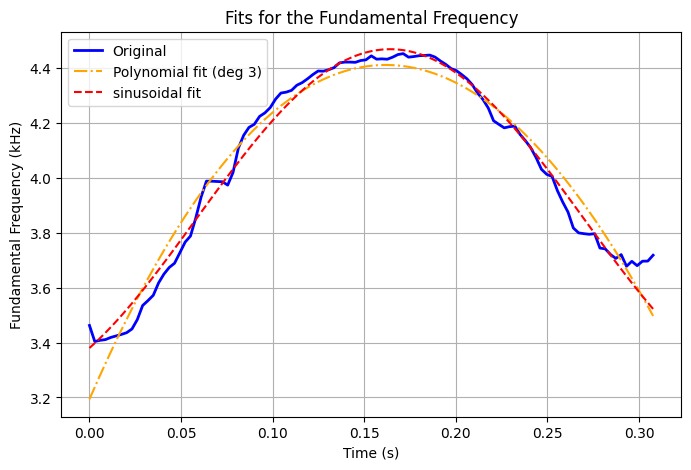

In [4]:
# Fit the fundamental frequency from the selected syllable

from matplotlib import pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from numpy.polynomial import Polynomial
from sklearn.metrics import r2_score, mean_squared_error


plot.fittings_comparison(btv_0.time, btv_0.ff, verbose=True)
# object = btv_0# .ff
# ff_exp_fit = fitting(object.time, object.ff, function="polynomial", verbose=False)[0]

sinusoidal fit metrics: R^2=0.9781, RMSE=49.6914
 sinusoidal: [ 3.85102324e+03  6.17624841e+02  2.36357999e+00 -1.37958816e-01]


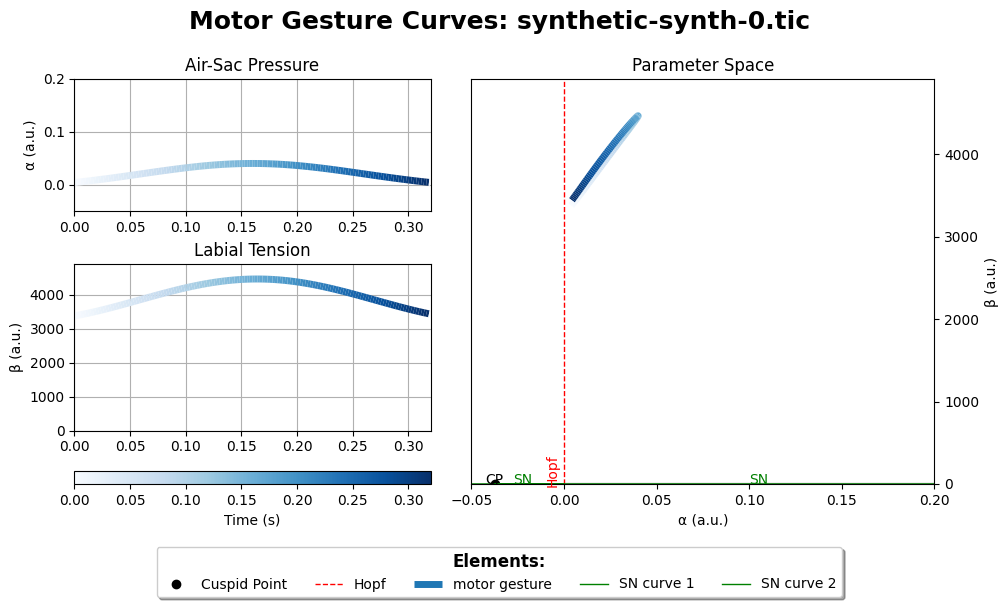

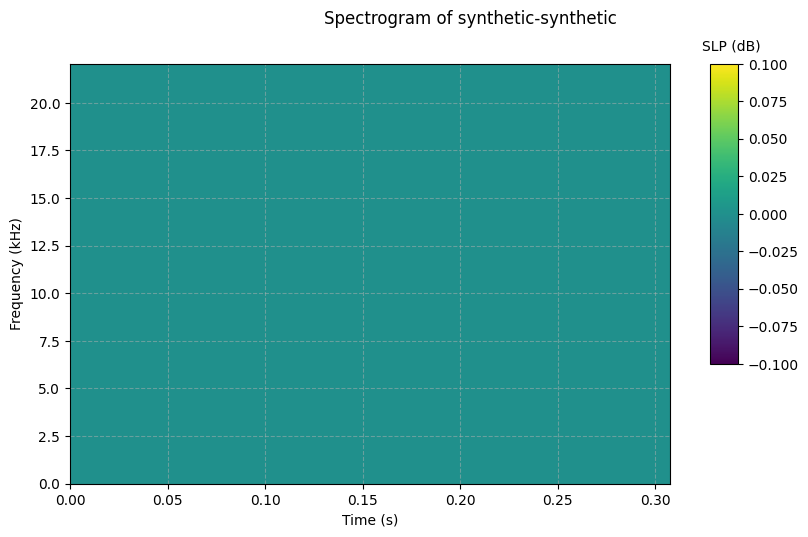

In [6]:
# Compute a fit for the ff of the selected syllable
fit_sin, params, metrics = fitting(btv_0.time, btv_0.ff, function="sinusoidal", verbose=True)

# Define the model to use and the over sampling rate
model = Model(ovsr=10)

# Create synthetic syllable
duration = btv_0.time_s[-1]
synthetic = Synthetic(duration=duration, proj_dirs=proj_dirs, sr=44100)
synthetic.initialize()

# Define the control parameters
curves = [
    gaussian(btv_0.time_s, 0.05, duration/2, sigma=0.1, a1=-0.01), # alpha 
    sinusoidal(btv_0.time_s, *params),                             # beta
]

synthetized = model.motor_gesture(synthetic, curves)
synthetized.acoustical_features(umbral_FF=1.4, n_fft=512, ff_method="yin")

# Plot the motor gesture and waveform and spectrogram generated
_ = ploter.alpha_beta(synthetized, save=False)
_ = ploter.spectrogram(synthetized, save=False)

# Play the synthetized syllable
synthetized.play()

In [ ]:
import numpy as np
# Define the control parameters, sinusoidal function: A + B sin (C t + D)
params1 = params.copy()
params1[0] = 0.3 # shitf beta to below
params1[1] = 0.1  # decrease amplitude
params1[2] += 0.1 # frequency
params1[3] += 0  # phase shift
print(f" Initial parameters: {params}\nModified parameters: {params1}")

# Define motor gesture curve functios
curves = [
    gaussian(btv_0.time_s, 0.01, duration/2, sigma=0.05, a1=0),  # alpha 
    # 0.01*np.ones_like(btv_0.time_s),
    sinusoidal(btv_0.time_s, *params1),                           # beta
]

# Define the synthetic syllable and compute its acoustical features
btv_synth = model.motor_gesture(synthetic, curves)
btv_synth.acoustical_features(umbral_FF=1.4, n_fft=512, ff_method="yin")

# Plot the motor gesture and waveform and spectrogram generated
_ = ploter.alpha_beta(btv_synth, save=False)
_ = ploter.spectrogram(btv_synth, save=False, ff=True)

# Play the synthetized syllable
btv_synth.play()

In [ ]:
from matplotlib import pyplot as plt

# ff_cte = btv_synth.ff
plt.figure()
plt.plot(btv_synth.ff, color="blue")
plt.plot(ff_cte, "--", color="red")
# plt.plot(btv_synth.mu1_curves[1], btv_synth.beta_bif)
# plt.plot(btv_synth.mu1_curves[0], btv_synth.beta_bif)
# plt.xlim((-0.1, 0.3))
plt.show()

In [ ]:
plt.figure()
plt.plot(100 * np.abs(btv_synth.ff - ff_cte) / np.abs(ff_cte))

In the following example we are going to vary the amplitude offset and function amplitude for generate more diverse data. The other parameters well keep constant, to not loose the "shape" of the syllable

In [ ]:
import pandas as pd
import numpy as np


limit_beta = (-0.3, 1)
limit_alpha = (-0.05, 0.3)

samples_generated = 0
total_samples = 100
folder = "synthetic_samples/"
function = "sinusoidal"
cv = pd.DataFrame(columns=['filename', 'alpha_params', 'beta_params', "class", "id_class"])
cv

# while samples_generated < total_samples:

_, params = fitting(btv_0, function=function, verbose=False)
params1 = params.copy()
params1[0] = np.random.uniform(*limit_beta) # shift beta to within limit_beta range
# params1[1] = 0.1  # decrease amplitude
params1